<a href="https://colab.research.google.com/github/RajeshkhannaBhuthkuri/SummerSchool_Project_IIEST_Rajeshkhanna/blob/main/CA_NB1A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 1A

# Baseline Implementation of the Classical Nagel-Schreckenberg Cellular Automata Model

---

## Research Project

**Adaptive Non-Uniform Cellular Automata with Dynamic Rule Evolution (A-NUCA-DREM) for Energy-Aware Autonomous EV Platooning under Mixed Traffic Conditions**

---

### Author

Dr. B. Rajeshkhanna Bhuthkuri

## Notebook Objective

This notebook implements the **classical Nagel-Schreckenberg (NaSch) Cellular Automata traffic model**.

This notebook serves as the baseline implementation before introducing

- Non-uniform Cellular Automata
- Dynamic Rule Evolution
- Battery-aware EV Platooning
- Deep Learning

The notebook reproduces the classical NaSch traffic model proposed in

Nagel, K., & Schreckenberg, M. (1992).

"A Cellular Automaton Model for Freeway Traffic."

Journal de Physique I France.

# Mathematical Formulation

The highway is represented by a one-dimensional lattice

\[
\Omega=\{1,2,\cdots,L\}
\]

where

L = number of road cells.

Each vehicle is represented as

\[
S_i(t)=
(x_i,v_i)
\]

where

\[
x_i
\]

Vehicle Position

\[
v_i
\]

Vehicle Speed

The four NaSch transition rules are

### Rule 1

Acceleration

\[
v_i=\min(v_i+1,v_{max})
\]

### Rule 2

Braking

\[
v_i=\min(v_i,d_i)
\]

### Rule 3

Randomization

With probability

\[
p
\]

\[
v_i=v_i-1
\]

### Rule 4

Movement

\[
x_i=x_i+v_i
\]

These rules are applied simultaneously to every vehicle.

In [ ]:
# ==========================================================
# Import Libraries
# ==========================================================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.animation as animation

from dataclasses import dataclass

import random
import seaborn as sns

from IPython.display import HTML

plt.style.use("ggplot")

%matplotlib inline

In [ ]:
# ==========================================================
# Simulation Parameters
# ==========================================================

ROAD_LENGTH = 200

NUM_LANES = 1

NUM_VEHICLES = 40

MAX_SPEED = 5

SLOW_PROBABILITY = 0.30

TIME_STEPS = 200

CELL_LENGTH = 7.5

TIME_INTERVAL = 1

CURRENT_CA_RULE = "NaSch"

SEED = 42

random.seed(SEED)

np.random.seed(SEED)

print("="*60)
print("Classical NaSch Traffic Simulator")
print("="*60)

Classical NaSch Traffic Simulator


In [ ]:
# ==========================================================
# Vehicle Class
# ==========================================================

@dataclass

class Vehicle:

    vehicle_id:int

    position:int

    speed:int

    acceleration:float=0

    lane:int=0

    soc:float=100

    energy:float=0

    platoon_id:int=-1

    current_rule:str="NaSch"

    history_position:list=None

    history_speed:list=None

    def __post_init__(self):

        self.history_position=[]

        self.history_speed=[]

    def save_history(self):

        self.history_position.append(self.position)

        self.history_speed.append(self.speed)

In [ ]:
# ==========================================================
# Highway Class
# ==========================================================

class Highway:

    def __init__(self,length):

        self.length=length

        self.cells=-1*np.ones(length,dtype=int)

    def clear(self):

        self.cells[:]=-1

    def update(self,vehicles):

        self.clear()

        for vehicle in vehicles:

            self.cells[vehicle.position]=vehicle.vehicle_id

    def display(self):

        road=np.zeros(self.length)

        road[self.cells!=-1]=1

        return road

In [ ]:
# ==========================================================
# Vehicle Initialization
# ==========================================================

positions=np.random.choice(

    ROAD_LENGTH,

    NUM_VEHICLES,

    replace=False

)

positions=np.sort(positions)

vehicles=[]

for i,pos in enumerate(positions):

    speed=np.random.randint(1,MAX_SPEED)

    vehicles.append(

        Vehicle(

            vehicle_id=i,

            position=int(pos),

            speed=int(speed)

        )

    )

print("Vehicles Initialized Successfully")

print()

for vehicle in vehicles[:10]:

    print(vehicle)

Vehicles Initialized Successfully

Vehicle(vehicle_id=0, position=9, speed=3, acceleration=0, lane=0, soc=100, energy=0, platoon_id=-1, current_rule='NaSch', history_position=[], history_speed=[])
Vehicle(vehicle_id=1, position=15, speed=2, acceleration=0, lane=0, soc=100, energy=0, platoon_id=-1, current_rule='NaSch', history_position=[], history_speed=[])
Vehicle(vehicle_id=2, position=16, speed=2, acceleration=0, lane=0, soc=100, energy=0, platoon_id=-1, current_rule='NaSch', history_position=[], history_speed=[])
Vehicle(vehicle_id=3, position=18, speed=1, acceleration=0, lane=0, soc=100, energy=0, platoon_id=-1, current_rule='NaSch', history_position=[], history_speed=[])
Vehicle(vehicle_id=4, position=30, speed=4, acceleration=0, lane=0, soc=100, energy=0, platoon_id=-1, current_rule='NaSch', history_position=[], history_speed=[])
Vehicle(vehicle_id=5, position=45, speed=2, acceleration=0, lane=0, soc=100, energy=0, platoon_id=-1, current_rule='NaSch', history_position=[], histor

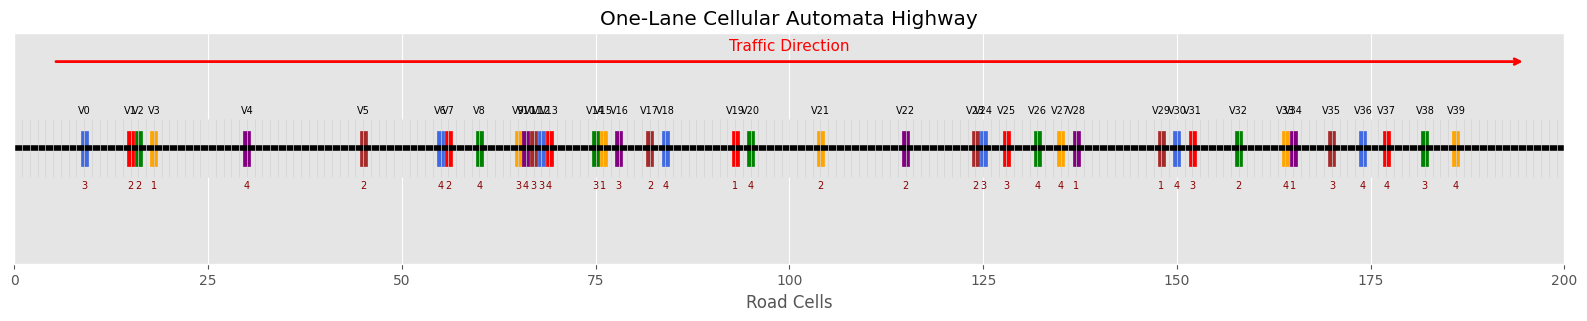

In [ ]:
# ==========================================================
# Improved Highway Visualization
# ==========================================================

fig, ax = plt.subplots(figsize=(20,3))

# Road
ax.hlines(
    y=0,
    xmin=0,
    xmax=ROAD_LENGTH,
    color='black',
    linewidth=4
)

# Cell Grid
for cell in range(ROAD_LENGTH+1):

    ax.vlines(
        cell,
        -0.25,
        0.25,
        color='lightgray',
        linewidth=0.5
    )

colors=["royalblue","red","green","orange","purple","brown"]

# Vehicles

for vehicle in vehicles:

    color=colors[vehicle.vehicle_id%len(colors)]

    rect=plt.Rectangle(

        (vehicle.position-0.45,-0.15),

        0.9,

        0.3,

        color=color

    )

    ax.add_patch(rect)

    ax.text(

        vehicle.position,

        0.30,

        f"V{vehicle.vehicle_id}",

        fontsize=7,

        ha='center'

    )

    ax.text(

        vehicle.position,

        -0.35,

        f"{vehicle.speed}",

        fontsize=7,

        color='darkred',

        ha='center'

    )

# Direction Arrow

ax.annotate(

    '',

    xy=(ROAD_LENGTH-5,0.75),

    xytext=(5,0.75),

    arrowprops=dict(

        arrowstyle='->',

        linewidth=2,

        color='red'

    )

)

ax.text(

    ROAD_LENGTH/2,

    0.85,

    "Traffic Direction",

    color='red',

    ha='center',

    fontsize=11

)

ax.set_xlim(0,ROAD_LENGTH)

ax.set_ylim(-1,1)

ax.set_yticks([])

ax.set_xlabel("Road Cells")

ax.set_title("One-Lane Cellular Automata Highway")

plt.show()

Notebook 1A — Part 2
Classical NaSch Rules and Simulation Engine

# Classical NaSch Transition Rules

At every simulation step, every vehicle follows four sequential rules.

1. Acceleration

2. Braking

3. Randomization

4. Movement

All vehicles are updated simultaneously.

The model assumes periodic boundary conditions (circular highway).

In [ ]:
# ==========================================================
# Compute Gap Between Vehicles
# ==========================================================

def compute_gap(vehicle_index, vehicles, road_length):
    """
    Computes the number of empty cells between the
    current vehicle and the vehicle ahead.

    Periodic Boundary Condition is used.
    """

    current_vehicle = vehicles[vehicle_index]

    current_position = current_vehicle.position

    positions = np.array([v.position for v in vehicles])

    diff = (positions - current_position) % road_length

    diff[diff == 0] = road_length

    gap = np.min(diff) - 1

    return int(gap)

In [ ]:
# ==========================================================
# Rule 1 : Acceleration
#
# v = min(v+1,vmax)
# ==========================================================

def acceleration_rule(vehicle):

    vehicle.speed = min(

        vehicle.speed + 1,

        MAX_SPEED

    )

In [ ]:
# ==========================================================
# Rule 2 : Braking
#
# v=min(v,gap)
# ==========================================================

def braking_rule(vehicle, gap):

    vehicle.speed = min(

        vehicle.speed,

        gap

    )

In [ ]:
# ==========================================================
# Rule 3 : Randomization
# ==========================================================

def randomization_rule(vehicle):

    if vehicle.speed > 0:

        if random.random() < SLOW_PROBABILITY:

            vehicle.speed -= 1

In [ ]:
# ==========================================================
# Rule 4 : Movement
#
# x=x+v
# ==========================================================

def movement_rule(vehicle):

    vehicle.position = (

        vehicle.position +

        vehicle.speed

    ) % ROAD_LENGTH

In [ ]:
# ==========================================================
# Complete NaSch Update
# ==========================================================

def update_nasch(vehicles):

    # Sort vehicles according to road position
    vehicles.sort(key=lambda x: x.position)

    # Store the active rule
    for vehicle in vehicles:
        vehicle.current_rule = CURRENT_CA_RULE

    # Compute gaps
    gaps = []

    for i in range(len(vehicles)):

        gap = compute_gap(

            i,

            vehicles,

            ROAD_LENGTH

        )

        gaps.append(gap)

    # Rule 1 : Acceleration
    for vehicle in vehicles:

        acceleration_rule(vehicle)

    # Rule 2 : Braking
    for vehicle, gap in zip(vehicles, gaps):

        braking_rule(vehicle, gap)

    # Rule 3 : Randomization
    for vehicle in vehicles:

        randomization_rule(vehicle)

    # Rule 4 : Movement
    for vehicle in vehicles:

        movement_rule(vehicle)

        vehicle.save_history()

In [ ]:
# ==========================================================
# Traffic Simulator Class
# ==========================================================

class TrafficSimulator:

    def __init__(self,
                 vehicles,
                 road_length,
                 simulation_steps):

        self.vehicles = vehicles
        self.road_length = road_length
        self.simulation_steps = simulation_steps

        self.history = []

        self.speed_history = []

        self.flow_history = []

        self.density_history = []

    def record_state(self):

        state = np.zeros(self.road_length)

        for vehicle in self.vehicles:

            state[vehicle.position] = 1

        self.history.append(state)

        avg_speed = np.mean([v.speed for v in self.vehicles])

        density = len(self.vehicles) / self.road_length

        flow = avg_speed * density

        self.speed_history.append(avg_speed)

        self.density_history.append(density)

        self.flow_history.append(flow)

    def run(self):

        self.record_state()

        for step in range(self.simulation_steps):

            update_nasch(self.vehicles)

            self.record_state()

        print("="*60)
        print("Simulation Completed Successfully")
        print("="*60)

In [ ]:
# ==========================================================
# Run NaSch Simulation
# ==========================================================

simulator = TrafficSimulator(

    vehicles,

    ROAD_LENGTH,

    TIME_STEPS

)

simulator.run()

Simulation Completed Successfully


In [ ]:
# ==========================================================
# Vehicle State Table
# ==========================================================

vehicle_df = pd.DataFrame({

    "Vehicle ID":[v.vehicle_id for v in vehicles],

    "Position":[v.position for v in vehicles],

    "Speed":[v.speed for v in vehicles],

    "Acceleration":[v.acceleration for v in vehicles],

    "Lane":[v.lane for v in vehicles],

    "SOC":[v.soc for v in vehicles],

    "Current Rule":[v.current_rule for v in vehicles]

})

vehicle_df.head(15)

,Vehicle ID,Position,Speed,Acceleration,Lane,SOC,Current Rule
0,39,2,2,0,0,100,NaSch
1,0,5,2,0,0,100,NaSch
2,1,16,5,0,0,100,NaSch
3,2,22,5,0,0,100,NaSch
4,3,36,5,0,0,100,NaSch
5,4,56,5,0,0,100,NaSch
6,5,61,4,0,0,100,NaSch
7,6,67,5,0,0,100,NaSch
8,7,81,5,0,0,100,NaSch
9,8,89,5,0,0,100,NaSch


Notebook 1A — Part 3
Visualization and Traffic Analysis

# Visualization of Classical NaSch Traffic Dynamics

This section validates the implementation using graphical analysis.

The following visualizations are generated:

1. Space-Time Diagram
2. Vehicle Trajectories
3. Speed Distribution
4. Average Speed
5. Traffic Density
6. Fundamental Diagram
7. Animated Traffic

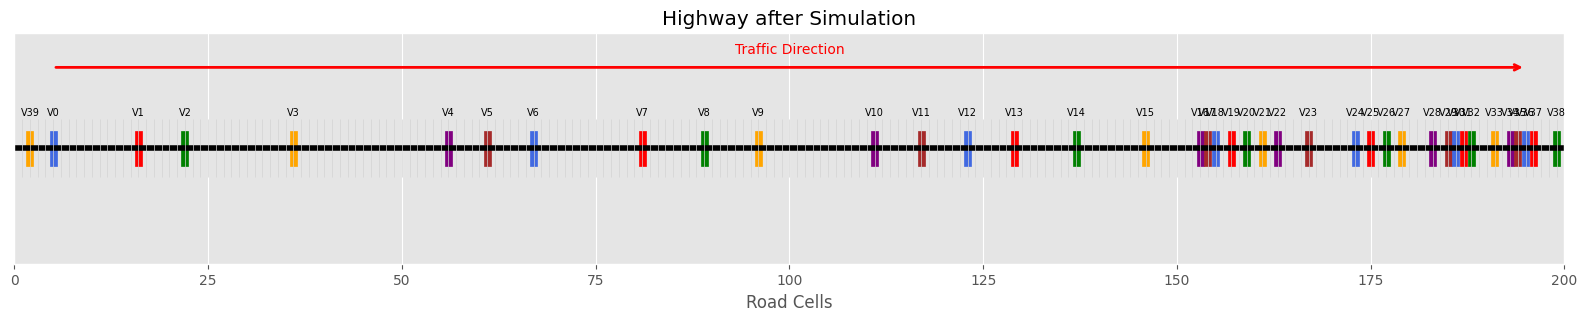

In [ ]:
# ==========================================================
# Cell 19 : Final Highway Visualization
# ==========================================================

road = Highway(ROAD_LENGTH)
road.update(vehicles)

fig, ax = plt.subplots(figsize=(20,3))

# Road
ax.hlines(0,0,ROAD_LENGTH,color='black',linewidth=4)

# Grid
for cell in range(ROAD_LENGTH+1):

    ax.vlines(
        cell,
        -0.25,
        0.25,
        color='lightgray',
        linewidth=0.5
    )

colors=["royalblue","red","green","orange","purple","brown"]

for vehicle in vehicles:

    color=colors[vehicle.vehicle_id%len(colors)]

    rect=plt.Rectangle(

        (vehicle.position-0.45,-0.15),

        0.9,

        0.3,

        color=color

    )

    ax.add_patch(rect)

    ax.text(

        vehicle.position,

        0.28,

        f"V{vehicle.vehicle_id}",

        fontsize=7,

        ha='center'

    )

ax.annotate(
    '',
    xy=(ROAD_LENGTH-5,0.7),
    xytext=(5,0.7),
    arrowprops=dict(
        arrowstyle='->',
        linewidth=2,
        color='red'
    )
)

ax.text(
    ROAD_LENGTH/2,
    0.82,
    "Traffic Direction",
    color='red',
    ha='center'
)

ax.set_xlim(0,ROAD_LENGTH)
ax.set_ylim(-1,1)

ax.set_yticks([])

ax.set_xlabel("Road Cells")

ax.set_title("Highway after Simulation")

plt.show()

In [ ]:
# ==========================================================
# Cell 20 : Simulation Statistics
# ==========================================================

print("="*60)
print("Simulation Statistics")
print("="*60)

print(f"Road Length        : {ROAD_LENGTH}")
print(f"Vehicles           : {NUM_VEHICLES}")
print(f"Maximum Speed      : {MAX_SPEED}")
print(f"Average Speed      : {np.mean(simulator.speed_history):.2f}")
print(f"Traffic Density    : {np.mean(simulator.density_history):.3f}")
print(f"Traffic Flow       : {np.mean(simulator.flow_history):.3f}")

Simulation Statistics
Road Length        : 200
Vehicles           : 40
Maximum Speed      : 5
Average Speed      : 2.19
Traffic Density    : 0.200
Traffic Flow       : 0.439


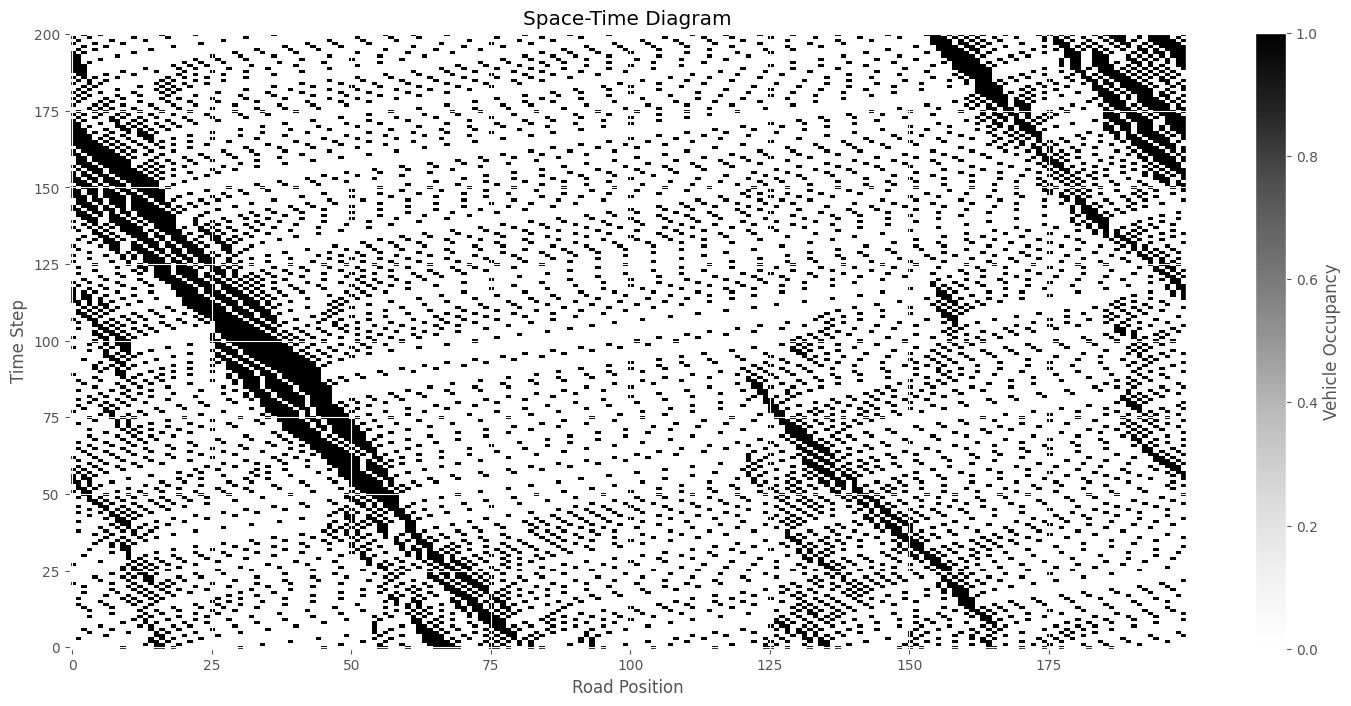

In [ ]:
# ==========================================================
# Cell 21 : Space-Time Diagram
# ==========================================================

history = np.array(simulator.history)

plt.figure(figsize=(18,8))

plt.imshow(

    history,

    cmap="Greys",

    origin="lower",

    aspect="auto"

)

plt.xlabel("Road Position")

plt.ylabel("Time Step")

plt.title("Space-Time Diagram")

plt.colorbar(label="Vehicle Occupancy")

plt.show()

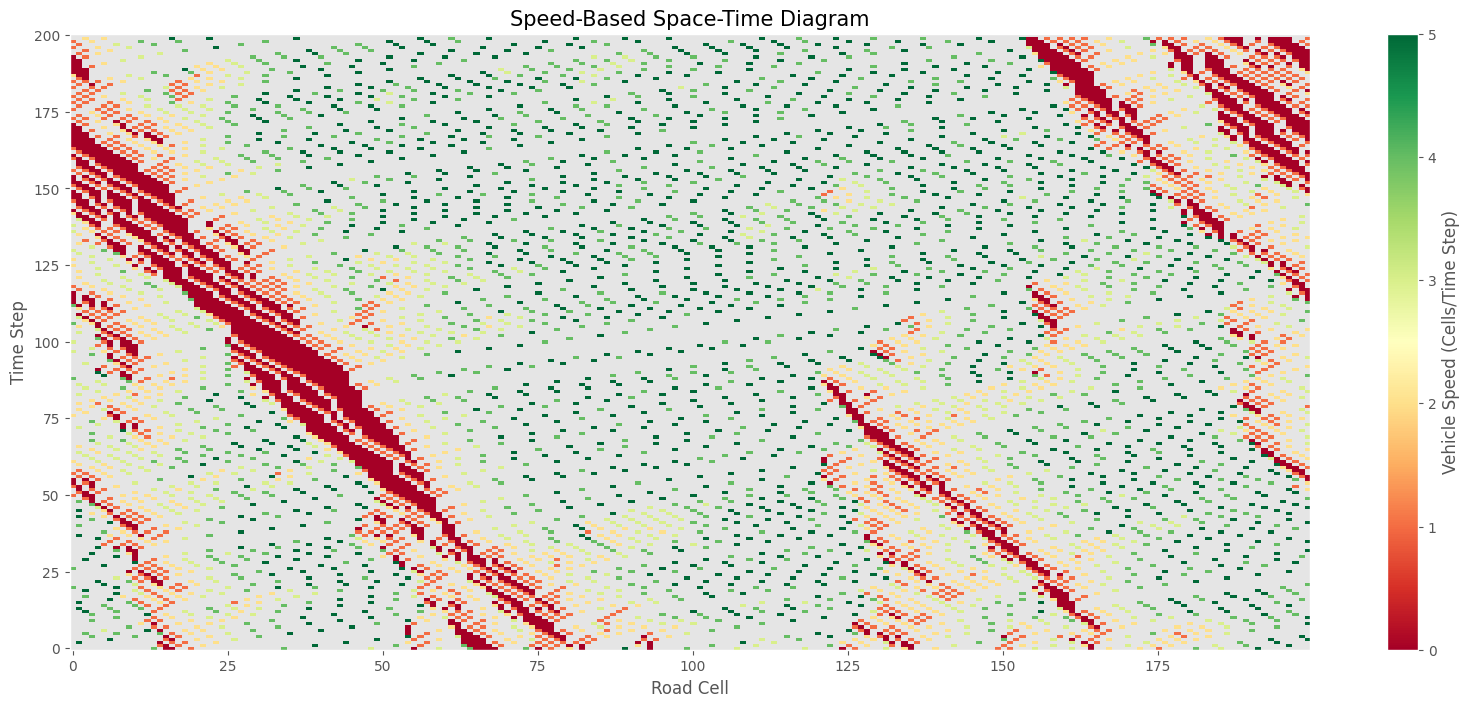

In [ ]:
# ==========================================================
# Cell 21 : Speed-Based Space-Time Diagram
# ==========================================================

speed_history = np.full(
    (TIME_STEPS + 1, ROAD_LENGTH),
    np.nan
)

for vehicle in vehicles:

    for t, (pos, speed) in enumerate(
        zip(vehicle.history_position, vehicle.history_speed)
    ):

        speed_history[t, pos] = speed

plt.figure(figsize=(20,8))

im = plt.imshow(

    speed_history,

    cmap="RdYlGn",      # Red -> Yellow -> Green

    origin="lower",

    aspect="auto",

    interpolation="nearest",

    vmin=0,

    vmax=MAX_SPEED

)

plt.xlabel("Road Cell", fontsize=12)

plt.ylabel("Time Step", fontsize=12)

plt.title("Speed-Based Space-Time Diagram", fontsize=15)

cbar = plt.colorbar(im)

cbar.set_label("Vehicle Speed (Cells/Time Step)")

plt.grid(False)

plt.show()

/tmp/ipykernel_955/2078738556.py:193: UserWarning: Glyph 128997 (\N{LARGE RED SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_955/2078738556.py:193: UserWarning: Glyph 128999 (\N{LARGE ORANGE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_955/2078738556.py:193: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_955/2078738556.py:193: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128997 (\N{LARGE RED SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128999 (\N{LARGE ORANGE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/d

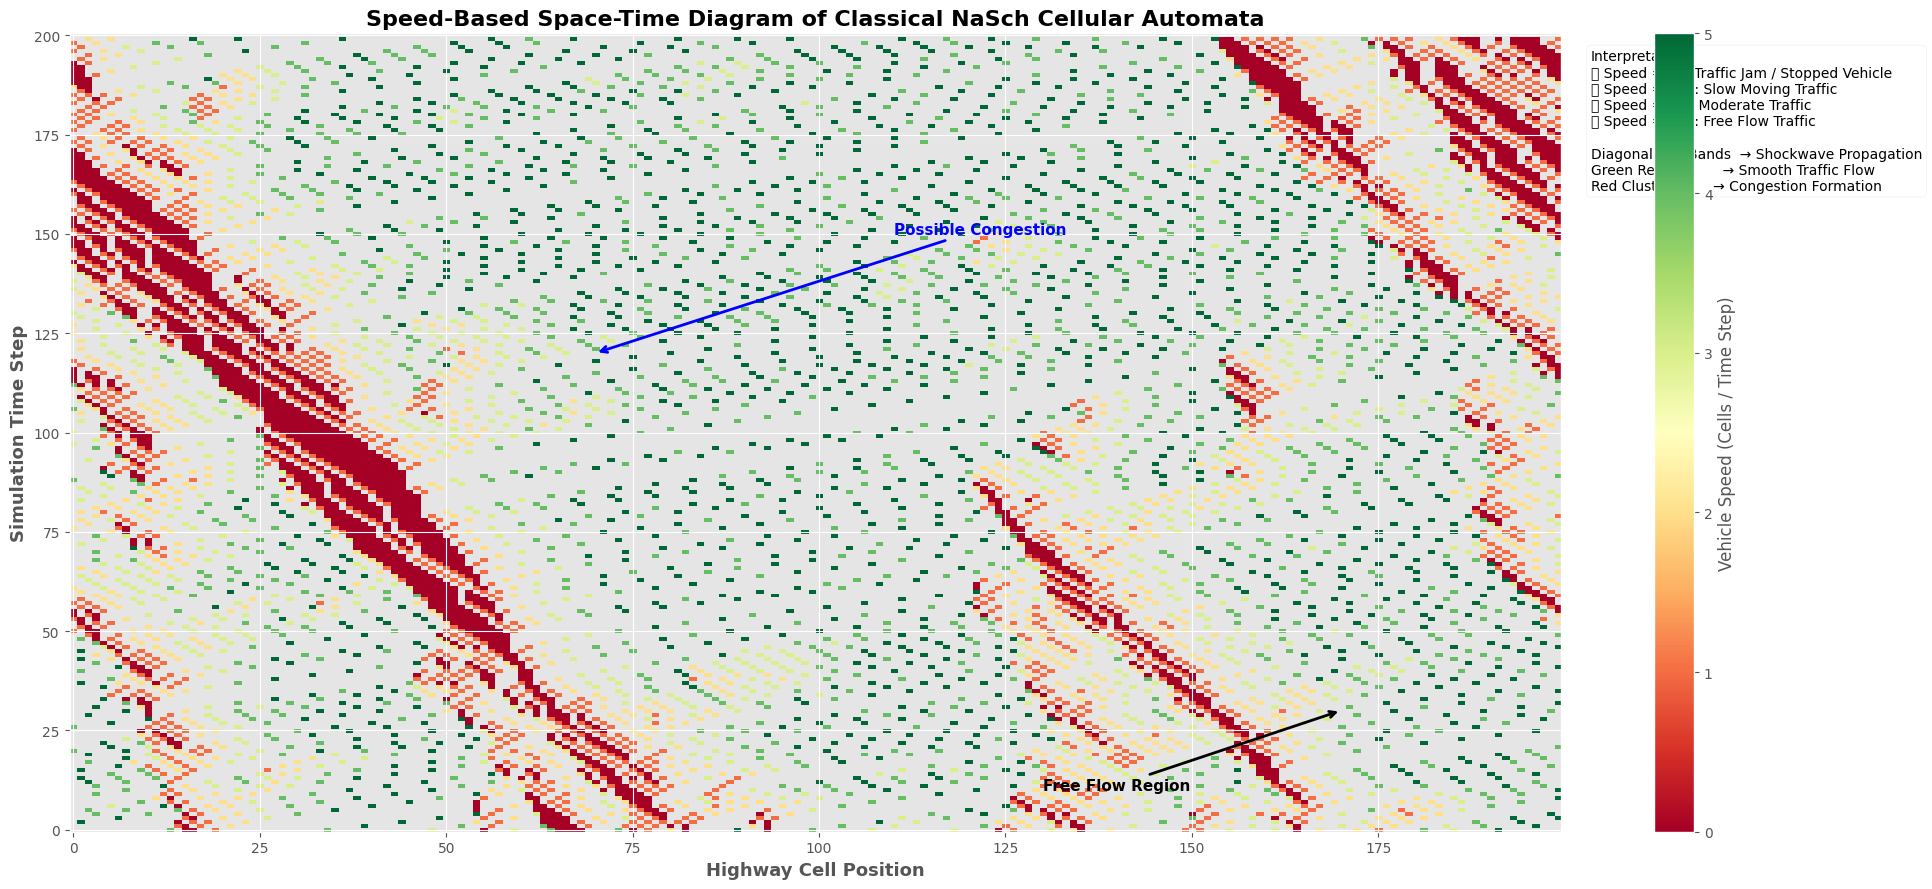

In [ ]:
# ==========================================================
# Cell 21 : Enhanced Space-Time Diagram
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------
# Create Speed Matrix
# --------------------------------------------

speed_history = np.full(
    (TIME_STEPS + 1, ROAD_LENGTH),
    np.nan
)

for vehicle in vehicles:

    for t, (pos, speed) in enumerate(
            zip(vehicle.history_position,
                vehicle.history_speed)):

        if t < TIME_STEPS + 1:
            speed_history[t, pos] = speed

# --------------------------------------------
# Plot
# --------------------------------------------

fig, ax = plt.subplots(figsize=(20,9))

im = ax.imshow(

    speed_history,

    cmap="RdYlGn",

    origin="lower",

    aspect="auto",

    interpolation="nearest",

    vmin=0,

    vmax=MAX_SPEED

)

# --------------------------------------------
# Axis Labels
# --------------------------------------------

ax.set_xlabel(
    "Highway Cell Position",
    fontsize=13,
    fontweight='bold'
)

ax.set_ylabel(
    "Simulation Time Step",
    fontsize=13,
    fontweight='bold'
)

ax.set_title(

    "Speed-Based Space-Time Diagram of Classical NaSch Cellular Automata",

    fontsize=16,

    fontweight='bold'

)

# --------------------------------------------
# Color Bar
# --------------------------------------------

cbar = plt.colorbar(im)

cbar.set_label(

    "Vehicle Speed (Cells / Time Step)",

    fontsize=12

)

# --------------------------------------------
# Interpretation Box
# --------------------------------------------

textstr = (
    "Interpretation\n"
    "🟥 Speed = 0  : Traffic Jam / Stopped Vehicle\n"
    "🟧 Speed = 1-2 : Slow Moving Traffic\n"
    "🟨 Speed = 3   : Moderate Traffic\n"
    "🟩 Speed = 4-5 : Free Flow Traffic\n\n"
    "Diagonal Red Bands  → Shockwave Propagation\n"
    "Green Regions       → Smooth Traffic Flow\n"
    "Red Clusters        → Congestion Formation"
)

props = dict(

    boxstyle='round',

    facecolor='white',

    alpha=0.9

)

ax.text(

    1.02,

    0.98,

    textstr,

    transform=ax.transAxes,

    fontsize=10,

    verticalalignment='top',

    bbox=props

)

# --------------------------------------------
# Highlight Possible Congestion Zone
# --------------------------------------------

ax.annotate(

    "Possible Congestion",

    xy=(70,120),

    xytext=(110,150),

    arrowprops=dict(

        arrowstyle="->",

        color='blue',

        lw=2

    ),

    fontsize=11,

    color='blue',

    fontweight='bold'

)

# --------------------------------------------
# Highlight Free Flow
# --------------------------------------------

ax.annotate(

    "Free Flow Region",

    xy=(170,30),

    xytext=(130,10),

    arrowprops=dict(

        arrowstyle="->",

        color='black',

        lw=2

    ),

    fontsize=11,

    color='black',

    fontweight='bold'

)

plt.tight_layout()

plt.show()

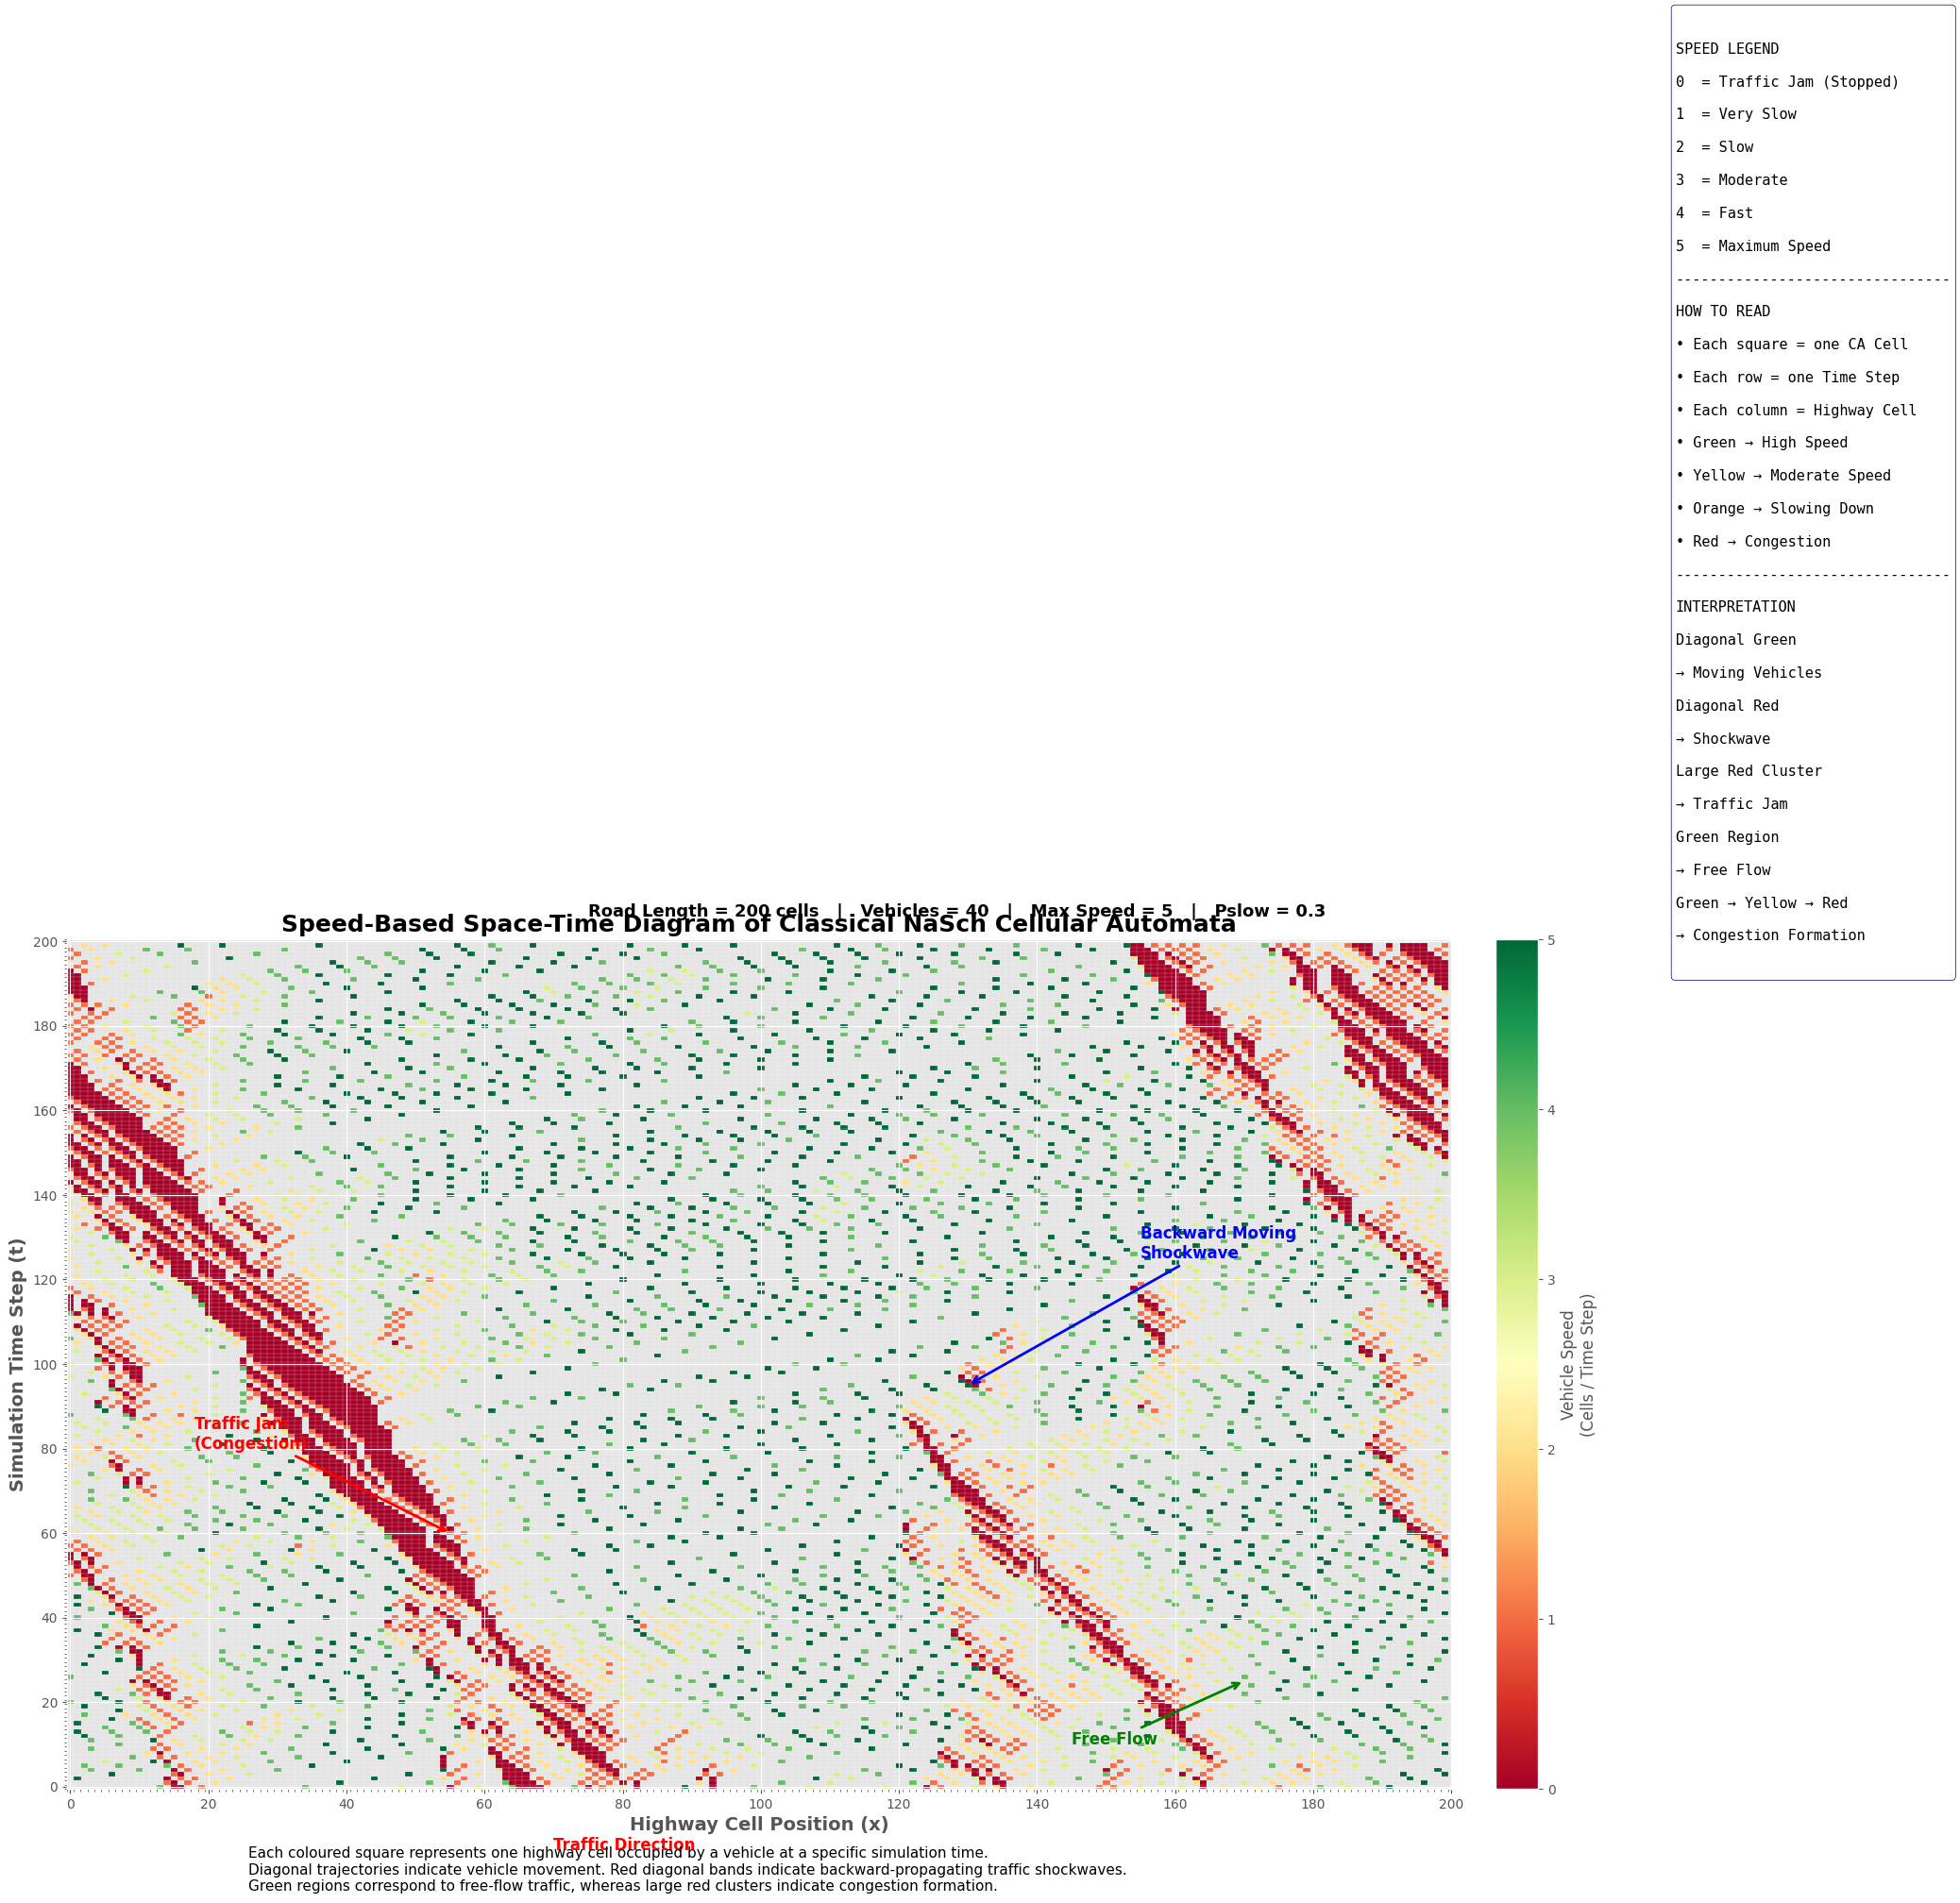

In [ ]:
# ==========================================================
# Cell 21 : Publication-Quality Space-Time Diagram
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# ----------------------------------------------------------
# Create Speed Matrix
# ----------------------------------------------------------

speed_history = np.full((TIME_STEPS+1, ROAD_LENGTH), np.nan)

for vehicle in vehicles:

    for t,(pos,speed) in enumerate(

        zip(vehicle.history_position,
            vehicle.history_speed)):

        if t < TIME_STEPS+1:

            speed_history[t,pos]=speed

# ----------------------------------------------------------
# Plot
# ----------------------------------------------------------

fig = plt.figure(figsize=(24,12))

ax = fig.add_axes([0.07,0.12,0.65,0.75])

im = ax.imshow(

    speed_history,

    cmap="RdYlGn",

    origin="lower",

    interpolation="nearest",

    aspect="auto",

    vmin=0,

    vmax=MAX_SPEED

)

# ----------------------------------------------------------
# Draw Grid (Cellular Automata Cells)
# ----------------------------------------------------------

ax.set_xticks(np.arange(-0.5, ROAD_LENGTH, 1), minor=True)
ax.set_yticks(np.arange(-0.5, TIME_STEPS+1, 1), minor=True)

ax.grid(which='minor',
        color='white',
        linewidth=0.15)

# ----------------------------------------------------------
# Major ticks
# ----------------------------------------------------------

ax.set_xticks(np.arange(0,ROAD_LENGTH+1,20))
ax.set_yticks(np.arange(0,TIME_STEPS+1,20))

# ----------------------------------------------------------
# Labels
# ----------------------------------------------------------

ax.set_xlabel(
    "Highway Cell Position (x)",
    fontsize=14,
    fontweight='bold'
)

ax.set_ylabel(
    "Simulation Time Step (t)",
    fontsize=14,
    fontweight='bold'
)

ax.set_title(
    "Speed-Based Space-Time Diagram of Classical NaSch Cellular Automata",
    fontsize=18,
    fontweight='bold'
)

# ----------------------------------------------------------
# Simulation Parameters
# ----------------------------------------------------------

fig.text(

    0.30,

    0.89,

    f"Road Length = {ROAD_LENGTH} cells   |   "
    f"Vehicles = {NUM_VEHICLES}   |   "
    f"Max Speed = {MAX_SPEED}   |   "
    f"Pslow = {SLOW_PROBABILITY}",

    fontsize=13,

    fontweight='bold'

)

# ----------------------------------------------------------
# Color Bar
# ----------------------------------------------------------

cbar=fig.colorbar(

    im,

    ax=ax,

    fraction=0.03,

    pad=0.03

)

cbar.set_label(

    "Vehicle Speed\n(Cells / Time Step)",

    fontsize=12

)

# ----------------------------------------------------------
# Explanation Box
# ----------------------------------------------------------

legend_text = """

SPEED LEGEND

0  = Traffic Jam (Stopped)

1  = Very Slow

2  = Slow

3  = Moderate

4  = Fast

5  = Maximum Speed

--------------------------------

HOW TO READ

• Each square = one CA Cell

• Each row = one Time Step

• Each column = Highway Cell

• Green → High Speed

• Yellow → Moderate Speed

• Orange → Slowing Down

• Red → Congestion

--------------------------------

INTERPRETATION

Diagonal Green

→ Moving Vehicles

Diagonal Red

→ Shockwave

Large Red Cluster

→ Traffic Jam

Green Region

→ Free Flow

Green → Yellow → Red

→ Congestion Formation

"""

fig.text(

    0.78,

    0.84,

    legend_text,

    fontsize=11,

    family='monospace',

    bbox=dict(

        facecolor='white',

        edgecolor='navy',

        boxstyle='round'

    )

)

# ----------------------------------------------------------
# Traffic Direction
# ----------------------------------------------------------

ax.annotate(

    "",

    xy=(105,-8),

    xytext=(40,-8),

    arrowprops=dict(

        arrowstyle="->",

        lw=3,

        color='red'

    )

)

ax.text(

    70,

    -15,

    "Traffic Direction",

    color='red',

    fontsize=12,

    fontweight='bold'

)

# ----------------------------------------------------------
# Highlight Congestion
# ----------------------------------------------------------

ax.annotate(

    "Traffic Jam\n(Congestion)",

    xy=(55,60),

    xytext=(18,80),

    color='red',

    fontsize=12,

    fontweight='bold',

    arrowprops=dict(

        arrowstyle="->",

        lw=2,

        color='red'

    )

)

# ----------------------------------------------------------
# Highlight Shockwave
# ----------------------------------------------------------

ax.annotate(

    "Backward Moving\nShockwave",

    xy=(130,95),

    xytext=(155,125),

    color='blue',

    fontsize=12,

    fontweight='bold',

    arrowprops=dict(

        arrowstyle="->",

        lw=2,

        color='blue'

    )

)

# ----------------------------------------------------------
# Highlight Free Flow
# ----------------------------------------------------------

ax.annotate(

    "Free Flow",

    xy=(170,25),

    xytext=(145,10),

    fontsize=12,

    color='green',

    fontweight='bold',

    arrowprops=dict(

        arrowstyle="->",

        lw=2,

        color='green'

    )

)

# ----------------------------------------------------------
# Footer
# ----------------------------------------------------------

fig.text(

    0.15,

    0.03,

    "Each coloured square represents one highway cell occupied by a vehicle at a specific simulation time.\n"
    "Diagonal trajectories indicate vehicle movement. Red diagonal bands indicate backward-propagating traffic shockwaves.\n"
    "Green regions correspond to free-flow traffic, whereas large red clusters indicate congestion formation.",

    fontsize=11

)

plt.show()

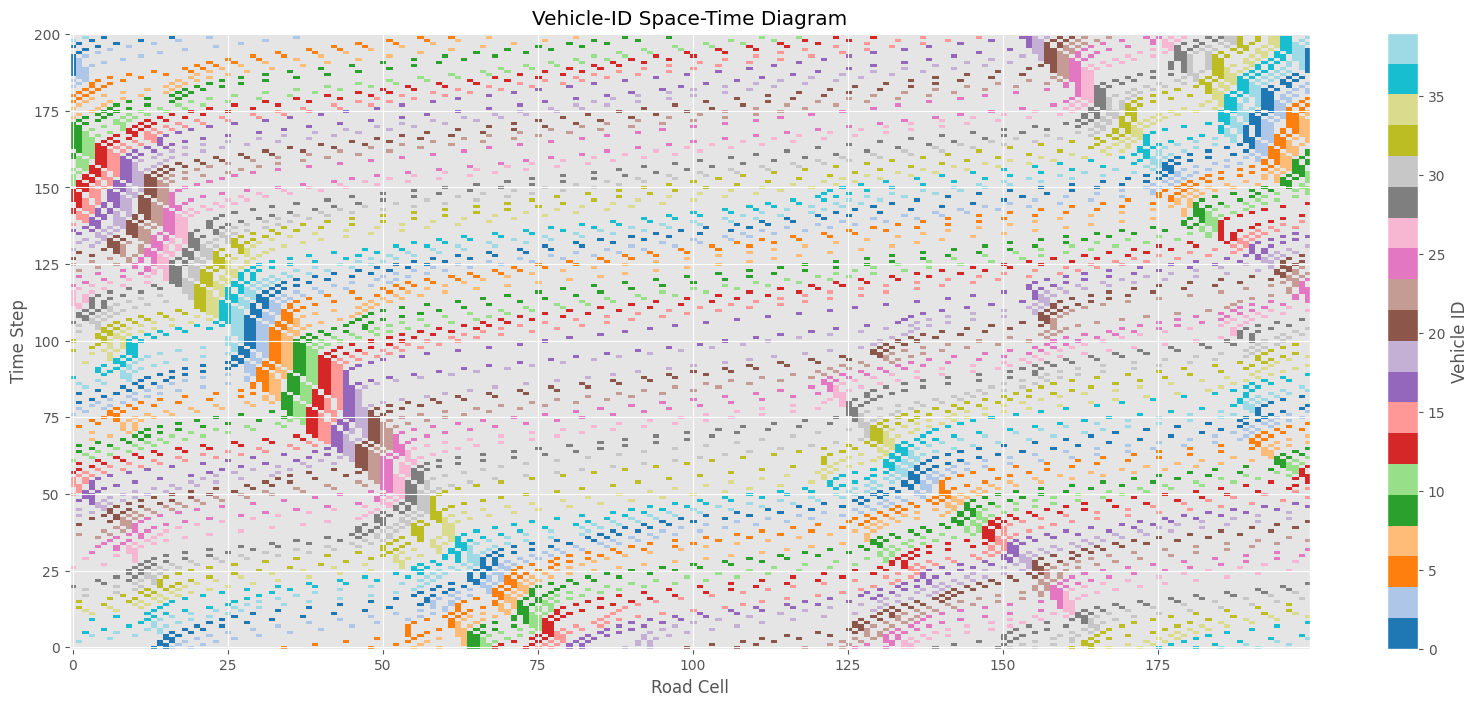

In [ ]:
vehicle_history = np.full(
    (TIME_STEPS+1, ROAD_LENGTH),
    np.nan
)

for vehicle in vehicles:

    for t,pos in enumerate(vehicle.history_position):

        vehicle_history[t,pos]=vehicle.vehicle_id

plt.figure(figsize=(20,8))

plt.imshow(

    vehicle_history,

    cmap='tab20',

    aspect='auto',

    origin='lower'

)

plt.xlabel("Road Cell")

plt.ylabel("Time Step")

plt.title("Vehicle-ID Space-Time Diagram")

plt.colorbar(label="Vehicle ID")

plt.show()

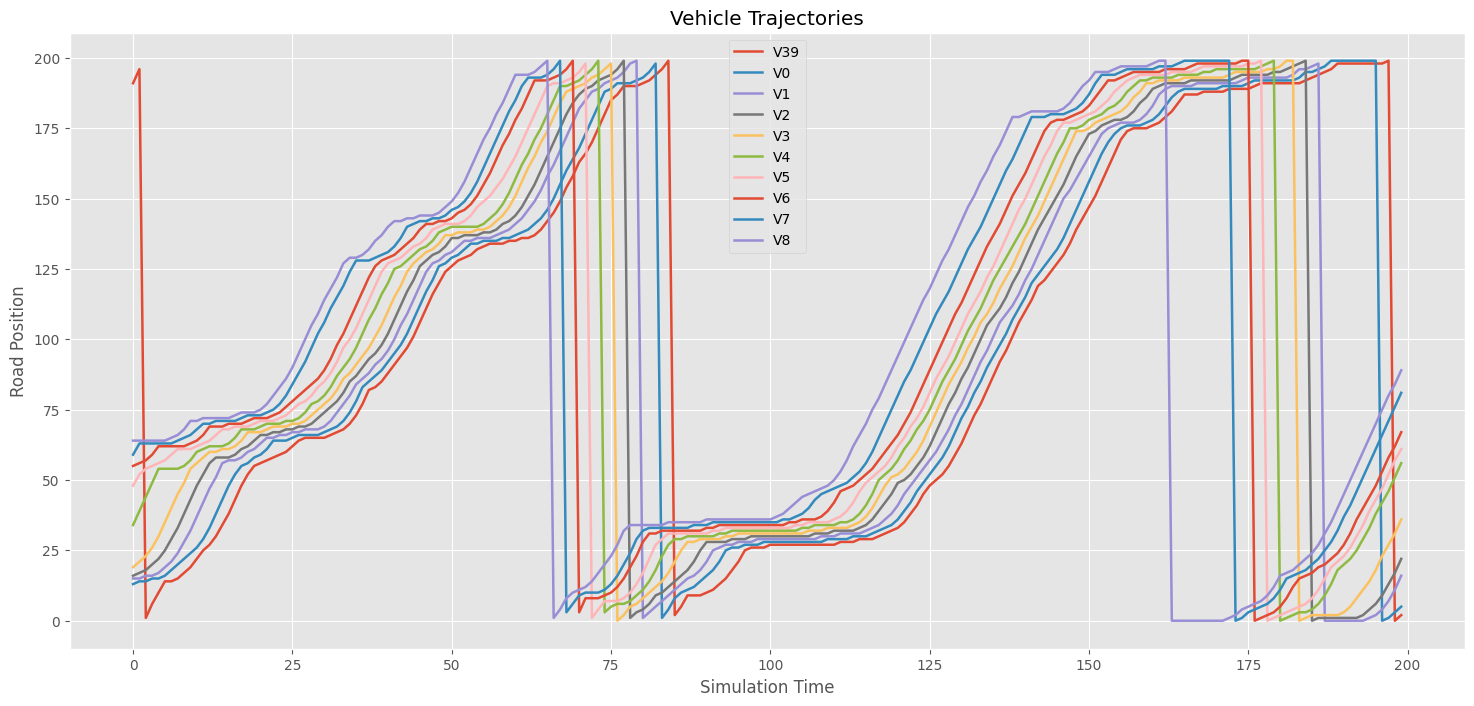

In [ ]:
# ==========================================================
# Cell 22 : Vehicle Trajectories
# ==========================================================

plt.figure(figsize=(18,8))

for vehicle in vehicles[:10]:

    plt.plot(

        vehicle.history_position,

        linewidth=1.8,

        label=f"V{vehicle.vehicle_id}"

    )

plt.xlabel("Simulation Time")

plt.ylabel("Road Position")

plt.title("Vehicle Trajectories")

plt.grid(True)

plt.legend()

plt.show()

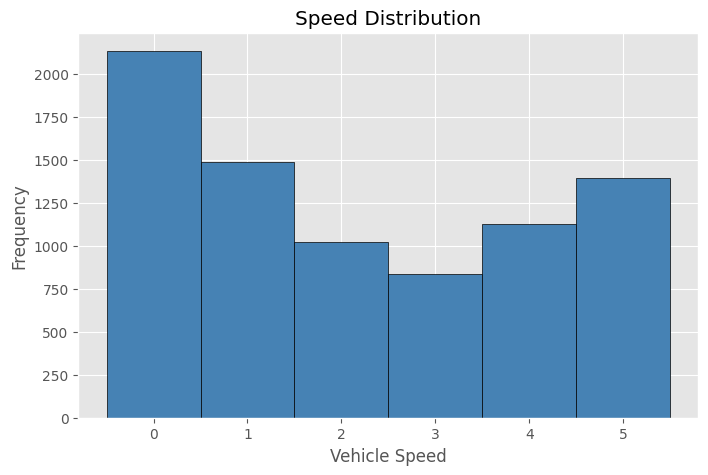

In [ ]:
# ==========================================================
# Cell 23 : Speed Distribution
# ==========================================================

speed=[]

for vehicle in vehicles:

    speed.extend(vehicle.history_speed)

plt.figure(figsize=(8,5))

plt.hist(

    speed,

    bins=np.arange(MAX_SPEED+2)-0.5,

    color='steelblue',

    edgecolor='black'

)

plt.xlabel("Vehicle Speed")

plt.ylabel("Frequency")

plt.title("Speed Distribution")

plt.show()

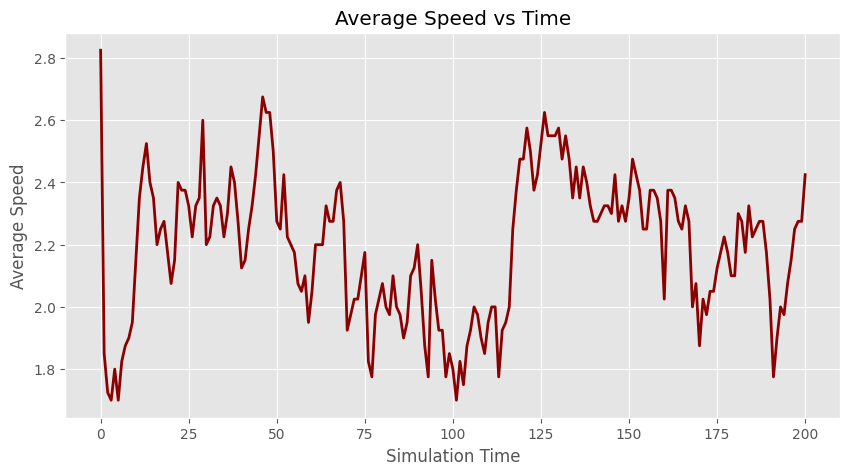

In [ ]:
# ==========================================================
# Cell 24 : Average Speed vs Time
# ==========================================================

plt.figure(figsize=(10,5))

plt.plot(

    simulator.speed_history,

    linewidth=2,

    color='darkred'

)

plt.xlabel("Simulation Time")

plt.ylabel("Average Speed")

plt.title("Average Speed vs Time")

plt.grid(True)

plt.show()

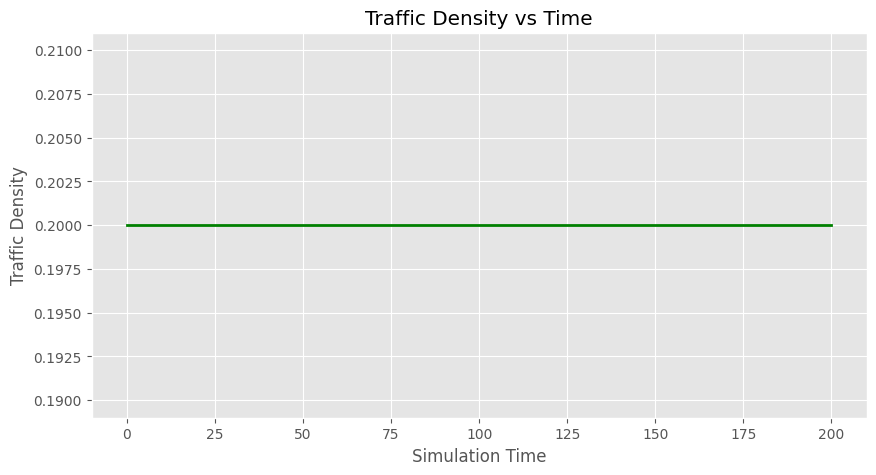

In [ ]:
# ==========================================================
# Cell 25 : Density vs Time
# ==========================================================

plt.figure(figsize=(10,5))

plt.plot(

    simulator.density_history,

    linewidth=2,

    color='green'

)

plt.xlabel("Simulation Time")

plt.ylabel("Traffic Density")

plt.title("Traffic Density vs Time")

plt.grid(True)

plt.show()

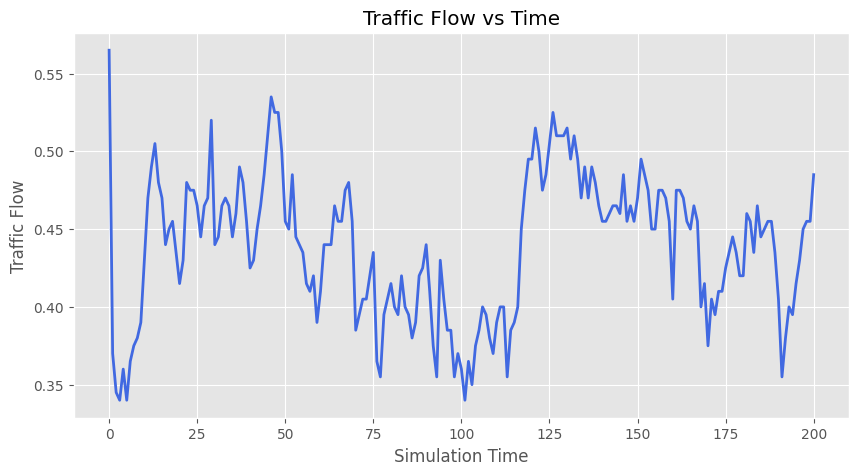

In [ ]:
# ==========================================================
# Cell 26 : Traffic Flow vs Time
# ==========================================================

plt.figure(figsize=(10,5))

plt.plot(

    simulator.flow_history,

    linewidth=2,

    color='royalblue'

)

plt.xlabel("Simulation Time")

plt.ylabel("Traffic Flow")

plt.title("Traffic Flow vs Time")

plt.grid(True)

plt.show()

In [ ]:
# ==========================================================
# Cell 27 : Experimental Fundamental Diagram
# ==========================================================

densities = np.linspace(0.05,0.95,19)

average_flows=[]

average_speeds=[]

for density in densities:

    vehicles_count=max(2,int(density*ROAD_LENGTH))

    positions=np.random.choice(

        ROAD_LENGTH,

        vehicles_count,

        replace=False

    )

    positions=np.sort(positions)

    test_vehicles=[]

    for i,pos in enumerate(positions):

        speed=np.random.randint(1,MAX_SPEED+1)

        test_vehicles.append(

            Vehicle(

                vehicle_id=i,

                position=int(pos),

                speed=int(speed)

            )

        )

    flow_history=[]

    speed_history=[]

    warmup=100

    simulation=200

    for t in range(warmup+simulation):

        update_nasch(test_vehicles)

        if t>=warmup:

            speed=np.mean([v.speed for v in test_vehicles])

            flow=density*speed

            flow_history.append(flow)

            speed_history.append(speed)

    average_flows.append(np.mean(flow_history))

    average_speeds.append(np.mean(speed_history))

print("Experimental Simulation Completed")

Experimental Simulation Completed


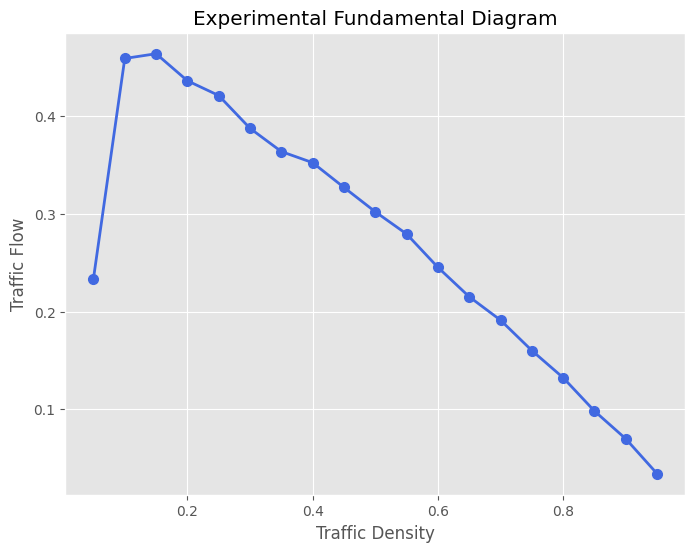

In [ ]:
# ==========================================================
# Cell 28 : Flow vs Density
# ==========================================================

plt.figure(figsize=(8,6))

plt.plot(

    densities,

    average_flows,

    'o-',

    linewidth=2,

    markersize=7,

    color='royalblue'

)

plt.xlabel("Traffic Density")

plt.ylabel("Traffic Flow")

plt.title("Experimental Fundamental Diagram")

plt.grid(True)

plt.show()

Notebook 1A — Part 4
Validation, Discussion and Research Transition

# Validation of the Classical NaSch Model

The Nagel-Schreckenberg (NaSch) model is validated by reproducing the
well-known traffic characteristics reported in the original paper.

The following properties are expected.

✓ Free-flow traffic

✓ Congestion formation

✓ Stop-and-go traffic

✓ Traffic shockwaves

✓ Fundamental flow-density relationship

These properties provide confidence that the implementation correctly
reproduces the original NaSch model.

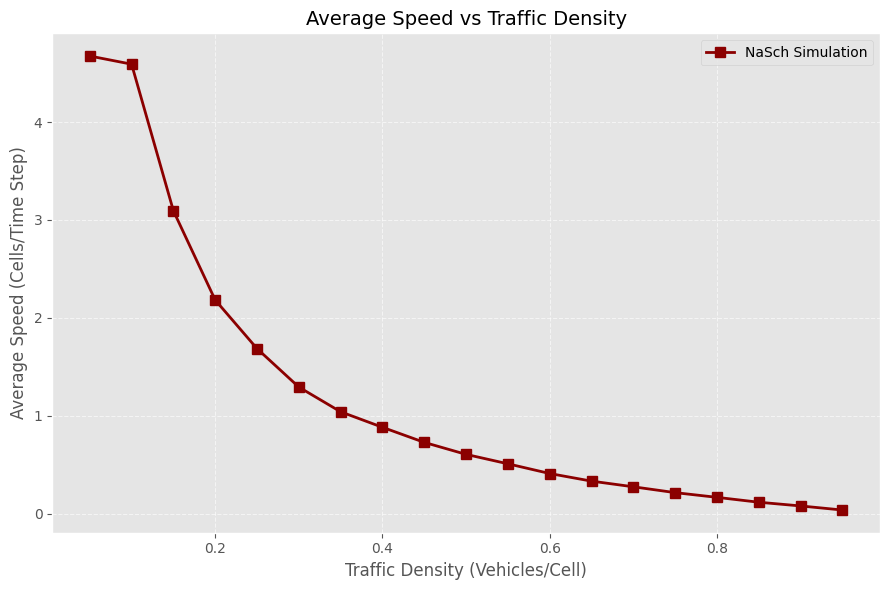

In [ ]:
# ==========================================================
# Cell 29 : Average Speed vs Density
# ==========================================================

plt.figure(figsize=(9,6))

plt.plot(
    densities,
    average_speeds,
    marker='s',
    linestyle='-',
    linewidth=2,
    markersize=7,
    color='darkred',
    label='NaSch Simulation'
)

plt.xlabel("Traffic Density (Vehicles/Cell)", fontsize=12)
plt.ylabel("Average Speed (Cells/Time Step)", fontsize=12)
plt.title("Average Speed vs Traffic Density", fontsize=14)

plt.grid(True, linestyle='--', alpha=0.6)

plt.legend()

plt.tight_layout()

plt.show()

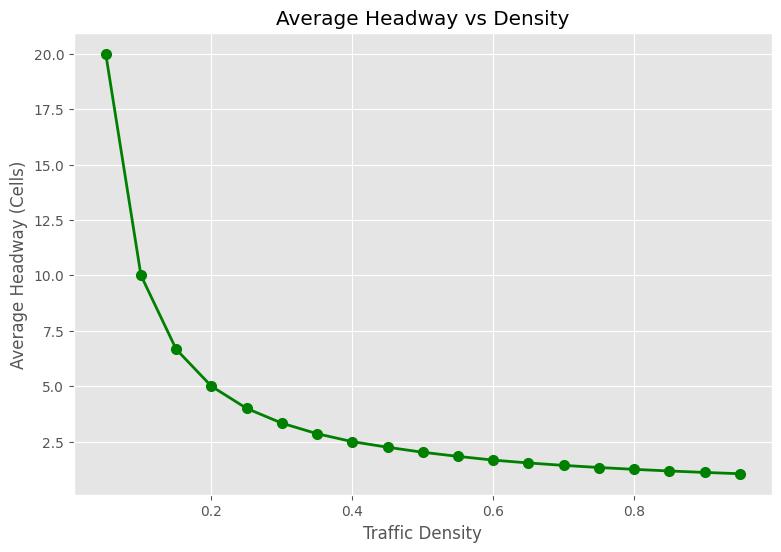

In [ ]:
# ==========================================================
# Cell 30 : Average Headway vs Density
# ==========================================================

average_headway = []

for density in densities:

    vehicles_count = max(2, int(density * ROAD_LENGTH))

    headway = ROAD_LENGTH / vehicles_count

    average_headway.append(headway)

plt.figure(figsize=(9,6))

plt.plot(
    densities,
    average_headway,
    marker='o',
    linewidth=2,
    markersize=7,
    color='green'
)

plt.xlabel("Traffic Density")

plt.ylabel("Average Headway (Cells)")

plt.title("Average Headway vs Density")

plt.grid(True)

plt.show()

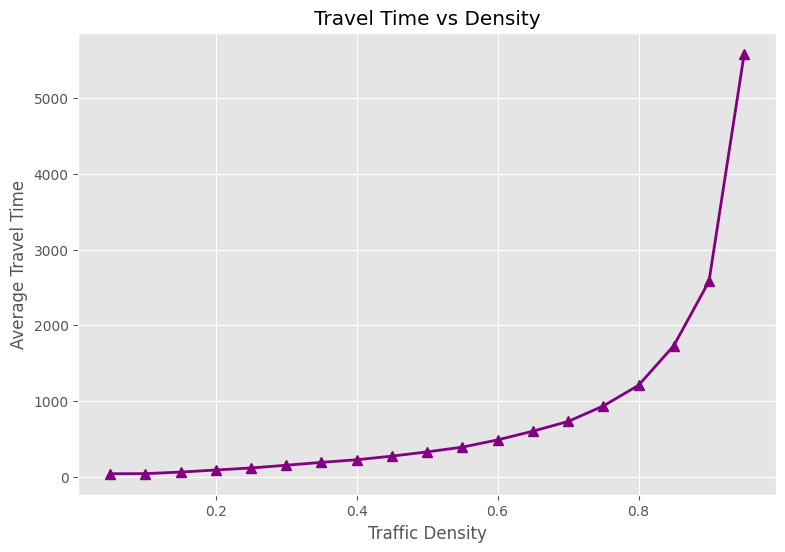

In [ ]:
# ==========================================================
# Cell 31 : Average Travel Time vs Density
# ==========================================================

travel_time = []

for speed in average_speeds:

    if speed > 0:

        travel_time.append(

            ROAD_LENGTH / speed

        )

    else:

        travel_time.append(np.nan)

plt.figure(figsize=(9,6))

plt.plot(

    densities,

    travel_time,

    marker='^',

    linewidth=2,

    markersize=7,

    color='purple'

)

plt.xlabel("Traffic Density")

plt.ylabel("Average Travel Time")

plt.title("Travel Time vs Density")

plt.grid(True)

plt.show()

In [ ]:
# ==========================================================
# Cell 32 : Results Table
# ==========================================================

results = pd.DataFrame({

    "Density": densities,

    "Average Speed": average_speeds,

    "Traffic Flow": average_flows,

    "Average Headway": average_headway,

    "Travel Time": travel_time

})

results

,Density,Average Speed,Traffic Flow,Average Headway,Travel Time
0,0.05,4.674500,0.233725,20.000000,42.785325
1,0.10,4.591250,0.459125,10.000000,43.561122
2,0.15,3.093167,0.463975,6.666667,64.658656
3,0.20,2.181500,0.436300,5.000000,91.680037
4,0.25,1.684800,0.421200,4.000000,118.708452
5,0.30,1.292000,0.387600,3.333333,154.798762
6,0.35,1.039500,0.363825,2.857143,192.400192
7,0.40,0.881125,0.352450,2.500000,226.982551
8,0.45,0.726910,0.327110,2.247191,275.137182
9,0.50,0.604343,0.302172,2.020202,330.937657


In [ ]:
# ==========================================================
# Cell 33 : Save Results
# ==========================================================

results.to_csv(

    "NaSch_Validation_Results.csv",

    index=False

)

vehicle_df.to_csv(

    "Vehicle_State_Table.csv",

    index=False

)

print("="*50)

print("Simulation Results Saved Successfully")

print("="*50)

Simulation Results Saved Successfully


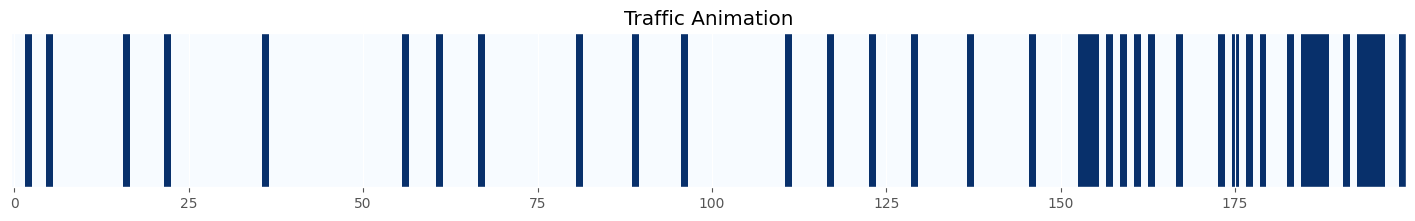

In [ ]:
# ==========================================================
# Cell 34 : Traffic Animation
# ==========================================================

fig, ax = plt.subplots(figsize=(18,2))

im = ax.imshow(

    history[0].reshape(1,-1),

    cmap="Blues",

    aspect="auto"

)

ax.set_yticks([])

ax.set_title("Traffic Animation")

def animate(i):

    im.set_data(

        history[i].reshape(1,-1)

    )

    return [im]

ani = animation.FuncAnimation(

    fig,

    animate,

    frames=len(history),

    interval=100,

    blit=True

)

HTML(ani.to_jshtml())

# Limitations of the Classical NaSch Model

Although the NaSch model is computationally efficient and capable of
reproducing macroscopic traffic behaviour, it has several limitations.

1. Every vehicle follows identical transition rules.

2. Vehicle heterogeneity is ignored.

3. Battery state is not considered.

4. Vehicle-to-Vehicle communication is absent.

5. Platoon formation is not supported.

6. Lane-changing behaviour is simplified.

7. Future traffic conditions are not predicted.

8. Traffic rules remain static throughout the simulation.

These limitations motivate the development of an Adaptive Non-Uniform
Cellular Automata framework.

# Research Gap

Existing Cellular Automata

↓

Uniform Rule

↓

Reactive Behaviour

↓

No Energy Awareness

↓

No Adaptive Intelligence

--------------------------------------------------

Proposed Research

↓

Adaptive Non-Uniform Cellular Automata

↓

Dynamic Rule Evolution

↓

Battery-aware EVs

↓

Predictive Traffic Intelligence

↓

Adaptive Platoon Formation

--------------------------------------------------

This notebook serves as the baseline implementation upon which the
proposed Adaptive Non-Uniform Cellular Automata (A-NUCA-DREM)
framework will be developed.

In [ ]:
# ==========================================================
# Save Simulation Results
# ==========================================================

summary_df.to_csv(

"NaSch_Simulation_Summary.csv",

index=False

)

history_df = pd.DataFrame(history)

history_df.to_csv(

"NaSch_Occupancy_History.csv",

index=False

)

print("Simulation Results Saved Successfully")

Simulation Results Saved Successfully


# Conclusions

The Classical Nagel-Schreckenberg Cellular Automata model has been
successfully implemented and validated.

Achievements

✓ Highway Initialization

✓ Vehicle Initialization

✓ Classical NaSch Rules

✓ Traffic Simulation

✓ Space-Time Diagram

✓ Fundamental Diagram

✓ Speed Analysis

✓ Traffic Animation

✓ Performance Metrics

This notebook establishes the baseline traffic simulator.

The next notebook extends this work by introducing

Adaptive Non-Uniform Cellular Automata (A-NUCA)

where different vehicles execute different transition rules based on
their local traffic conditions.